In [1]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import warnings
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import random
import os
warnings.filterwarnings('ignore')

c:\Users\Amine\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [3]:
seed_everything()

In [4]:
FEATURES = [       # the 10 features — input to the LSTM
    "return",
    "lag1",
    "lag5",
    "lag10",
    "ma10",
    "ma50",
    'price_vs_ma50',
    'high_low_range',
    "volatility5",
    "volatility10",
    "volatility20",
    "volatility60",
    'vol_ratio',
    "rsi",
    "macd",
    'volume_change',
    "volume_ratio"
]
TARGET = "volatility20"   # what we predict

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE   # lenovo legion with RTX 4060 ^_^

device(type='cuda')

In [6]:
class StockDataset(Dataset):
    """
    Simple PyTorch Dataset wrapper around our numpy arrays.
    Converts them to float32 tensors and moves to device.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [7]:
from functions import make_windows, fit_scaler, apply_scaler, split_data

def Transformation_Pipeline(data : pd.DataFrame, test_pct : float, val_pct : float, W : int, features : list, target : str, BatchSize : int) -> tuple:

    train_data, test_data = split_data(data, test_pct=test_pct)
    train_data, val_data = split_data(train_data, test_pct=val_pct)

    X_train, y_train = make_windows(train_data, W=W, features=features, target=target)
    X_val, y_val = make_windows(val_data, W=W, features=features, target=target)
    X_test, y_test = make_windows(test_data, W=W, features=features, target=target)

    scaler = fit_scaler(X_train=X_train)

    X_train_scaled = apply_scaler(X_train, scaler=scaler)
    X_val_scaled = apply_scaler(X_val, scaler=scaler)
    X_test_scaled = apply_scaler(X_test, scaler=scaler)

    train_loader = DataLoader(StockDataset(X_train_scaled, y_train), batch_size=BatchSize, shuffle=True)
    val_loader = DataLoader(StockDataset(X_val_scaled, y_val), batch_size=BatchSize, shuffle=False,)
    test_loader = DataLoader(StockDataset(X_test_scaled, y_test), batch_size=BatchSize, shuffle=False)

    return (train_loader, val_loader, test_loader)

# LSTM

In [8]:
class StockLSTM(nn.Module):
    """
    LSTM model for stock return prediction.
 
    Architecture:
        Input  → LSTM layers → Dropout → Linear → Output
 
    Input shape:  (batch_size, W, n_features)
    Output shape: (batch_size, 1)
    """
    def __init__(self, n_features: int, hidden_size: int, num_layers: int, dropout: float):
        super(StockLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size   = n_features,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout      = dropout if num_layers > 1 else 0,  # dropout only between layers
            batch_first  = True    # input shape: (batch, seq, features)
        )
 
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(hidden_size, 1)
 
    def forward(self, x):
        # x shape: (batch_size, W, n_features)
 
        lstm_out, _ = self.lstm(x)
        # lstm_out shape: (batch_size, W, hidden_size)
 
        # take only the last timestep's output
        # because we want to predict the next day after the sequence ends
        last_out = lstm_out[:, -1, :]
        # last_out shape: (batch_size, hidden_size)
 
        out = self.dropout(last_out)
        out = self.linear(out)
        # out shape: (batch_size, 1)
 
        return out.squeeze(1)   # shape: (batch_size,)

# GRU

In [9]:
class StockGRU(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0,
            batch_first = True
        )
        self.dropout = nn.Dropout(dropout)
        self.linear  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_out   = gru_out[:, -1, :]
        out        = self.dropout(last_out)
        out        = self.linear(out)
        return out.squeeze(1)

In [10]:
def quantile_loss(preds, target, quantile=0.63):
    """
    Calculate the pinball/quantile loss.
    quantile: float between 0 and 1 (e.g., 0.9 for the 90th percentile).
    """
    errors = target - preds
    loss = torch.max((quantile - 1) * errors, quantile * errors)
    return loss.mean()

In [11]:
from functions import make_windows, apply_scaler, fit_scaler

def train_trial(trial, data, n_features, epochs, model_name):
    """
    Trains one model configuration suggested by Optuna.
    Returns best validation loss.
    """

    # ── suggest hyperparameters
    hidden_size   = trial.suggest_categorical('hidden_size',  [32, 64, 128, 192, 256])
    num_layers    = trial.suggest_int('num_layers',           1, 5)
    dropout       = trial.suggest_float('dropout',            0.1, 0.7)
    learning_rate = trial.suggest_float('lr',                 1e-4, 5e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size',   [32, 48, 64, 128, 192, 256])
    patience      = trial.suggest_int('patience',             10, 25)
    W = trial.suggest_categorical('W',  [20, 30, 40, 50, 60, 70, 80, 90, 100, 110])
    quantile =  trial.suggest_float('quantile', 0.6, 0.7)

    train_loader, val_loader, _ = Transformation_Pipeline(
        data=data,
        test_pct=0.2,
        val_pct=0.2,
        W=W,
        features=FEATURES,
        target=TARGET,
        BatchSize=batch_size
    )
 
    # ── model
    if model_name == 'LSTM':
        model = StockLSTM(n_features, hidden_size, num_layers, dropout).to(DEVICE)
    else:
        model = StockGRU(n_features, hidden_size, num_layers, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    criterionTrain = quantile_loss
    criterionVal = nn.MSELoss()

    best_val_loss    = float('inf')
    patience_counter = 0
 
    for epoch in range(1, epochs + 1):
 
        # train
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterionTrain(model(X_batch), y_batch, quantile=quantile)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
 
        # validate
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_losses.append(criterionVal(model(X_batch), y_batch).item())
 
        val_loss = np.mean(val_losses)
        scheduler.step(val_loss)
 
        # early stopping
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
 
        # Optuna pruning — cuts unpromising trials early
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
 
    return best_val_loss
 
 
# ── Optuna objective ──────────────────────────────────────────────────────────
def make_objective(data, n_features, epochs, model_name):
    def objective(trial):
        return train_trial(trial, data, n_features, epochs, model_name)
    return objective

In [12]:
import joblib
from functions import compute_features, load_ticker, split_data

TICKER = "AAPL"
PERIOD    = "16y"

data = load_ticker(TICKER, PERIOD)

# ── run Optuna study
N_TRIALS  = 100     # number of Optuna trials — increase to 100 if you have time
EPOCHS    = 100     # max epochs per trial — early stopping will cut most short
sampler = TPESampler(seed=42)      # TPE = Tree-structured Parzen Estimator
                                       # smarter than random search
n_features = len(FEATURES)

[*********************100%***********************]  1 of 1 completed


# Tuning the LSTM

[I 2026-04-20 15:58:23,225] A new study created in memory with name: stock_lstm_tuning


Starting Optuna search — 100 trials on cuda, model : LSTM


  0%|          | 0/100 [00:00<?, ?it/s]

train=3172 rows, test=793 rows, split date=2023-02-21
train=2537 rows, test=635 rows, split date=2020-08-12
number of instances : 2467
number of instances : 565
number of instances : 723


Best trial: 0. Best value: 2.28059e-06:   1%|          | 1/100 [00:03<05:59,  3.63s/it]

...

[I 2026-04-20 16:23:26,127] Trial 97 finished with value: 1.4011006636375594e-06 and parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.6418871066429701, 'lr': 0.007944822792817599, 'batch_size': 48, 'patience': 25, 'W': 60, 'quantile': 0.6024273988343785}. Best is trial 86 with value: 1.2873450240628397e-06.
train=3172 rows, test=793 rows, split date=2023-02-21
train=2537 rows, test=635 rows, split date=2020-08-12
number of instances : 2477
number of instances : 575
number of instances : 733


Best trial: 86. Best value: 1.28735e-06:  99%|█████████▉| 99/100 [25:13<00:10, 10.62s/it]

[I 2026-04-20 16:23:36,309] Trial 98 finished with value: 1.5344885232101053e-06 and parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.5528770732316637, 'lr': 0.006649037406947494, 'batch_size': 48, 'patience': 24, 'W': 60, 'quantile': 0.6039708130362256}. Best is trial 86 with value: 1.2873450240628397e-06.
train=3172 rows, test=793 rows, split date=2023-02-21
train=2537 rows, test=635 rows, split date=2020-08-12
number of instances : 2477
number of instances : 575
number of instances : 733


Best trial: 86. Best value: 1.28735e-06: 100%|██████████| 100/100 [25:25<00:00, 15.25s/it]


[I 2026-04-20 16:23:48,271] Trial 99 finished with value: 1.444735801214847e-06 and parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.5116927435683363, 'lr': 0.010850845116068857, 'batch_size': 48, 'patience': 25, 'W': 60, 'quantile': 0.6098467970631799}. Best is trial 86 with value: 1.2873450240628397e-06.

Best trial:
  Val loss : 0.000001
  Params   :
    hidden_size          : 64
    num_layers           : 2
    dropout              : 0.13425006919751267
    lr                   : 0.0020733744699150854
    batch_size           : 48
    patience             : 23
    W                    : 60
    quantile             : 0.6176637604495911


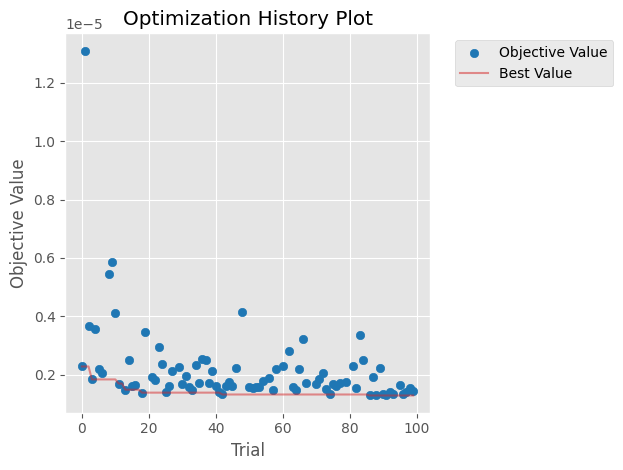

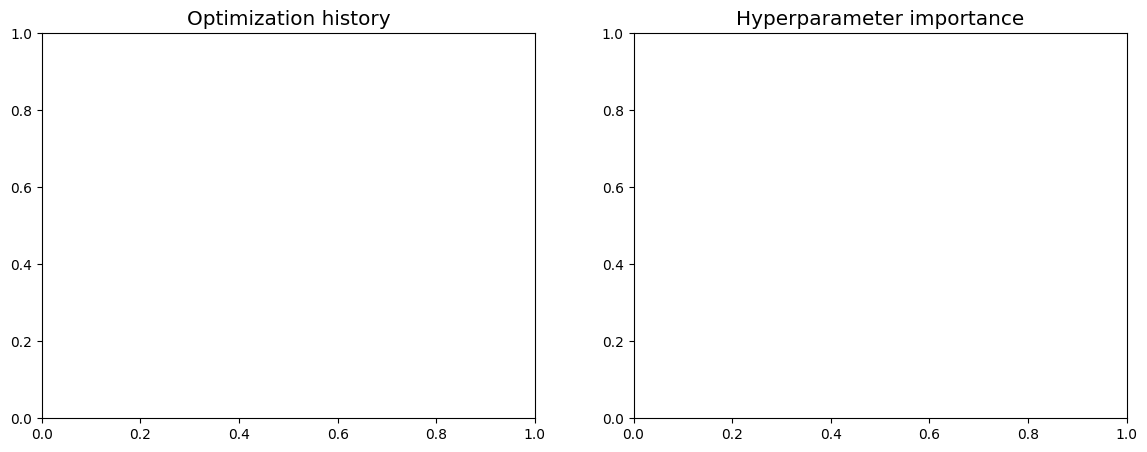

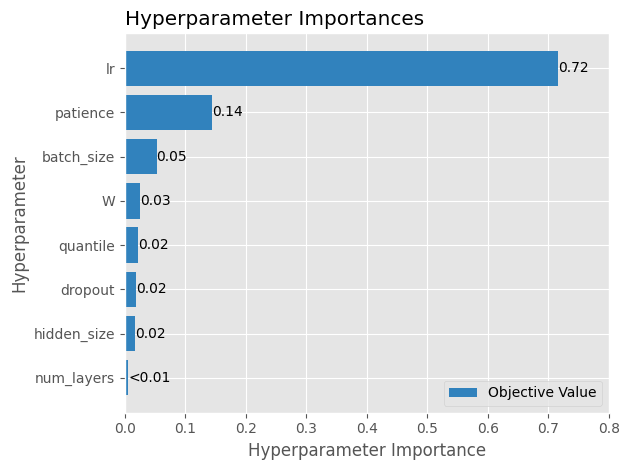

In [13]:
pruner_LSTM  = MedianPruner(
    n_startup_trials  = 5,         # don't prune first 5 trials
    n_warmup_steps    = 10,        # don't prune first 10 epochs of each trial
)
 
study_LSTM = optuna.create_study(
    direction = 'minimize',        # minimize validation loss
    sampler   = sampler,
    pruner    = pruner_LSTM,
    study_name= 'stock_lstm_tuning'
)

print(f"Starting Optuna search — {N_TRIALS} trials on {DEVICE}, model : LSTM")
print("=" * 60)
 
study_LSTM.optimize(
    make_objective(data, n_features, EPOCHS, model_name='LSTM'),
    n_trials  = N_TRIALS,
    show_progress_bar = True
)
 
# ── results
print("\n" + "=" * 60)
print("Best trial:")
print(f"  Val loss : {study_LSTM.best_trial.value:.6f}")
print(f"  Params   :")
for k, v in study_LSTM.best_trial.params.items():
    print(f"    {k:20s} : {v}")
 
# ── save study
joblib.dump(study_LSTM, '../models/optuna_study_LSTM.pkl')

# ── plot results
try:
    import matplotlib.pyplot as plt
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plt.sca(axes[0])
    plot_optimization_history(study_LSTM)
    axes[0].set_title('Optimization history')

    plt.sca(axes[1])
    plot_param_importances(study_LSTM)
    axes[1].set_title('Hyperparameter importance')

    plt.tight_layout()
    plt.savefig('../assets/optuna_results_LSTM.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Plotting skipped: {e}")

# Tuning the GRU

[I 2026-04-20 16:23:49,765] A new study created in memory with name: stock_lstm_tuning


Starting Optuna search — 100 trials on cuda, model : GRU


  0%|          | 0/100 [00:00<?, ?it/s]

train=3172 rows, test=793 rows, split date=2023-02-21
train=2537 rows, test=635 rows, split date=2020-08-12
number of instances : 2467
number of instances : 565
number of instances : 723


Best trial: 0. Best value: 2.1868e-06:   1%|          | 1/100 [00:03<05:45,  3.49s/it]

...

[I 2026-04-20 17:01:41,111] Trial 97 pruned. 
train=3172 rows, test=793 rows, split date=2023-02-21
train=2537 rows, test=635 rows, split date=2020-08-12
number of instances : 2447
number of instances : 545
number of instances : 703


Best trial: 74. Best value: 1.08737e-06:  99%|█████████▉| 99/100 [38:05<00:28, 28.78s/it]

[I 2026-04-20 17:01:54,993] Trial 98 pruned. 
train=3172 rows, test=793 rows, split date=2023-02-21
train=2537 rows, test=635 rows, split date=2020-08-12
number of instances : 2487
number of instances : 585
number of instances : 743


Best trial: 74. Best value: 1.08737e-06: 100%|██████████| 100/100 [38:06<00:00, 22.86s/it]


[I 2026-04-20 17:01:56,222] Trial 99 pruned. 

Best trial:
  Val loss : 0.000001
  Params   :
    hidden_size          : 256
    num_layers           : 4
    dropout              : 0.5049696839451802
    lr                   : 0.001423301166151796
    batch_size           : 32
    patience             : 20
    W                    : 50
    quantile             : 0.6413430231856577


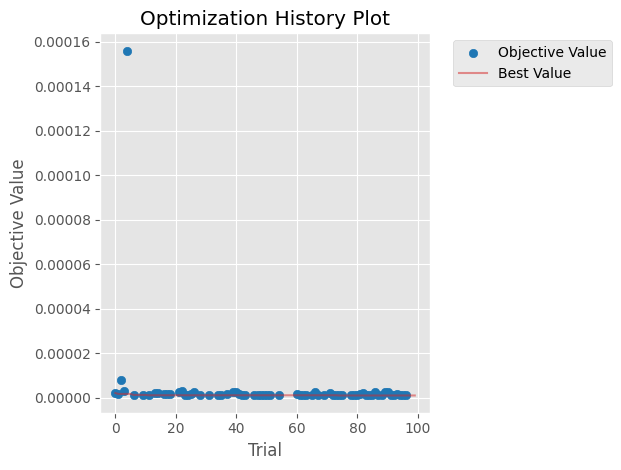

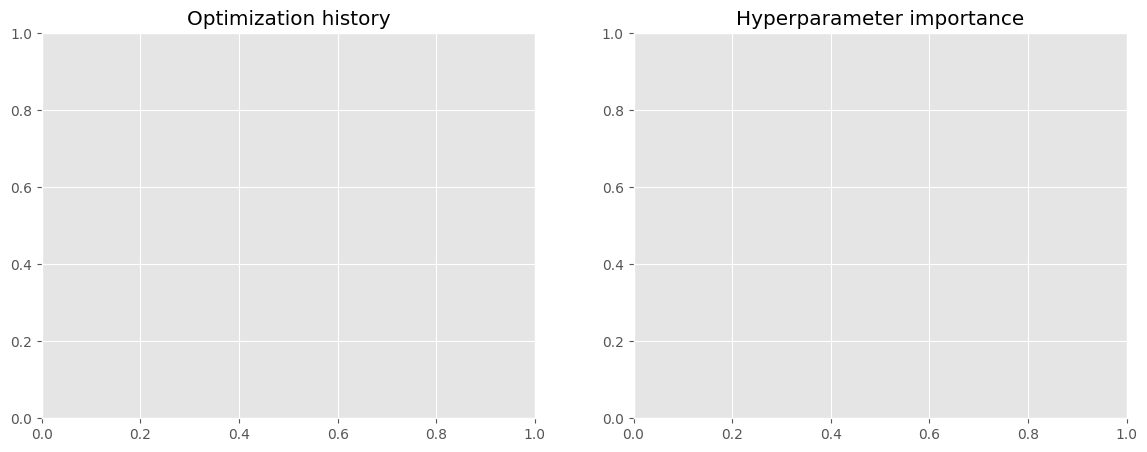

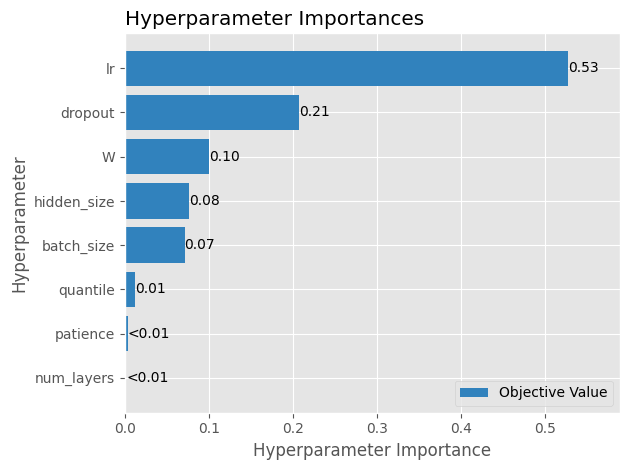

In [14]:
pruner_GRU  = MedianPruner(
    n_startup_trials  = 5,         # don't prune first 5 trials
    n_warmup_steps    = 10,        # don't prune first 10 epochs of each trial
)
 
study_GRU = optuna.create_study(
    direction = 'minimize',        # minimize validation loss
    sampler   = sampler,
    pruner    = pruner_GRU,
    study_name= 'stock_lstm_tuning'
)


print(f"Starting Optuna search — {N_TRIALS} trials on {DEVICE}, model : GRU")
print("=" * 60)
 
study_GRU.optimize(
    make_objective(data, n_features, EPOCHS, model_name='GRU'),
    n_trials  = N_TRIALS,
    show_progress_bar = True
)
 
# ── results
print("\n" + "=" * 60)
print("Best trial:")
print(f"  Val loss : {study_GRU.best_trial.value:.6f}")
print(f"  Params   :")
for k, v in study_GRU.best_trial.params.items():
    print(f"    {k:20s} : {v}")
 
# ── save study
joblib.dump(study_GRU, '../models/optuna_study_GRU.pkl')

# ── plot results
try:
    import matplotlib.pyplot as plt
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plt.sca(axes[0])
    plot_optimization_history(study_GRU)
    axes[0].set_title('Optimization history')

    plt.sca(axes[1])
    plot_param_importances(study_GRU)
    axes[1].set_title('Hyperparameter importance')

    plt.tight_layout()
    plt.savefig('../assets/optuna_results_GRU.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Plotting skipped: {e}")